# Solver Strategy Comparison

gaussx provides two solver strategies that pair `solve` + `logdet`:

- **DenseSolver** — structural dispatch (Cholesky for PSD, etc.)
- **CGSolver** — iterative CG solve + stochastic Lanczos logdet

This notebook compares them on the same problem.

For small-to-medium problems ($N \lesssim 5000$), direct factorization
(Cholesky for PSD systems) is optimal: $O(N^3/3)$ flops with
machine-precision accuracy. For larger problems, iterative methods like
conjugate gradients (CG) achieve useful accuracy in far fewer flops,
especially when the matrix is well-conditioned or a good preconditioner
is available.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Setup: PSD kernel matrix

In [2]:
key = jax.random.PRNGKey(0)
n = 50

# RBF kernel + noise
x = jnp.linspace(0, 5, n)
sq_dist = (x[:, None] - x[None, :]) ** 2
K = jnp.exp(-0.5 * sq_dist / 1.0**2) + 0.1 * jnp.eye(n)

op = lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)
b = jax.random.normal(key, (n,))

print(f"Problem size: {n}x{n}")

Problem size: 50x50


## DenseSolver

In [3]:
dense = gaussx.DenseSolver()

x_dense = dense.solve(op, b)
ld_dense = dense.logdet(op)

print("DenseSolver:")
print(f"  solve residual: {jnp.max(jnp.abs(op.mv(x_dense) - b)):.2e}")
print(f"  logdet: {ld_dense:.6f}")

DenseSolver:


  solve residual: 1.09e-14
  logdet: -91.659733


## CGSolver

The CGSolver pairs conjugate gradients for the linear solve with
stochastic Lanczos quadrature (SLQ) for the log-determinant. SLQ
exploits the identity $\log|A| = \operatorname{tr}(\log A)$ and then
uses Hutchinson's trace estimator: draw random probe vectors $z$ and
approximate $\operatorname{tr}(\log A) \approx
\frac{1}{P}\sum_{p=1}^P z_p^\top \log(A)\, z_p$.
Each quadratic form $z^\top \log(A)\, z$ is evaluated via a short
Lanczos decomposition, which produces a tridiagonal matrix whose
eigenvalues give accurate Gauss quadrature nodes for the spectral
integral. See Ubaru et al. (2017) for convergence analysis.

In [4]:
cg = gaussx.CGSolver(rtol=1e-8, atol=1e-8, max_steps=200, num_probes=50)

x_cg = cg.solve(op, b)
ld_cg = cg.logdet(op, key=jax.random.PRNGKey(42))

print("CGSolver:")
print(f"  solve residual: {jnp.max(jnp.abs(op.mv(x_cg) - b)):.2e}")
print(f"  logdet: {ld_cg:.6f}")

CGSolver:
  solve residual: 3.51e-09
  logdet: -90.873256


## Comparison

In [5]:
print(f"Solve difference: {jnp.max(jnp.abs(x_dense - x_cg)):.2e}")
print(f"Logdet difference: {jnp.abs(ld_dense - ld_cg):.4f}")

# True logdet for reference
ld_true = jnp.linalg.slogdet(K)[1]
print(f"\nTrue logdet:    {ld_true:.6f}")
print(f"Dense logdet:   {ld_dense:.6f}  (error: {jnp.abs(ld_dense - ld_true):.2e})")
print(f"CG logdet:      {ld_cg:.6f}  (error: {jnp.abs(ld_cg - ld_true):.4f})")

Solve difference: 3.41e-09
Logdet difference: 0.7865

True logdet:    -91.659733
Dense logdet:   -91.659733  (error: 0.00e+00)
CG logdet:      -90.873256  (error: 0.7865)


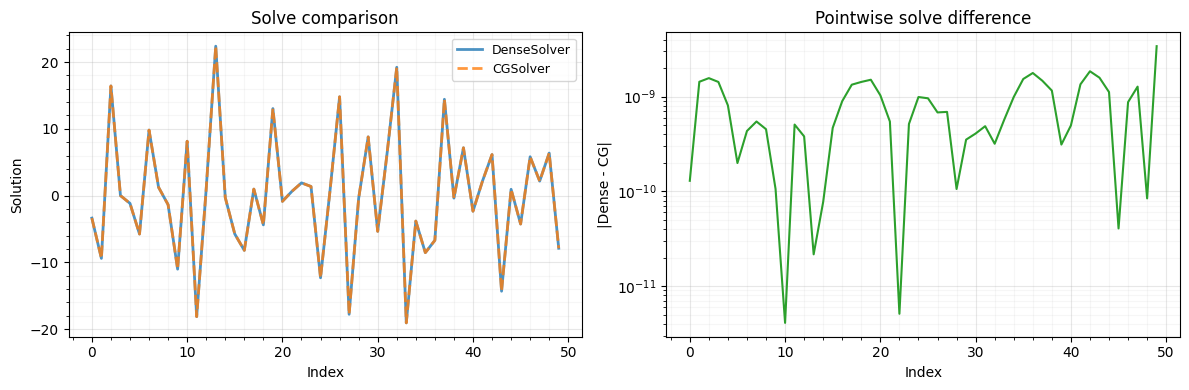

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Solve comparison
axes[0].plot(x_dense, "C0-", lw=2, label="DenseSolver", alpha=0.8)
axes[0].plot(x_cg, "C1--", lw=2, label="CGSolver", alpha=0.8)
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Solution")
axes[0].set_title("Solve comparison")
axes[0].legend(fontsize=9)
axes[0].grid(True, which="major", alpha=0.3)
axes[0].grid(True, which="minor", alpha=0.1)
axes[0].minorticks_on()

# Solve difference
axes[1].semilogy(jnp.abs(x_dense - x_cg), "C2-")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("|Dense - CG|")
axes[1].set_title("Pointwise solve difference")
axes[1].grid(True, which="major", alpha=0.3)
axes[1].grid(True, which="minor", alpha=0.1)
axes[1].minorticks_on()

plt.tight_layout()
plt.show()

## When to use which

| Strategy | Best for | Solve | Logdet |
|----------|----------|-------|--------|
| `DenseSolver` | Small-medium, structured | Exact (structural dispatch) | Exact |
| `CGSolver` | Large PSD, matrix-free | Iterative | Stochastic |

The `DenseSolver` is exact and exploits gaussx structural dispatch
(Kronecker, BlockDiag, LowRank, Diagonal fast paths).
The `CGSolver` works for any PSD operator, even matrix-free ones
where `as_matrix()` is unavailable, but the logdet is approximate.

The crossover point depends on hardware (GPU memory, FLOP throughput) and
matrix conditioning. On modern GPUs, Cholesky can handle
$N \sim 10{,}000$--$50{,}000$; beyond that, CG-based methods become
necessary.

## References

- Golub, G. H. & Van Loan, C. F. (2013). *Matrix Computations*. 4th edition,
  Johns Hopkins University Press.
- Ubaru, S., Chen, J., & Saad, Y. (2017). Fast estimation of
  $\operatorname{tr}(f(A))$ via stochastic Lanczos quadrature.
  *SIAM J. Matrix Analysis*, 38(4), 1075--1099.
- Hestenes, M. R. & Stiefel, E. (1952). Methods of conjugate gradients for
  solving linear systems. *Journal of Research of the National Bureau of
  Standards*, 49(6), 409--436.